In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the  test sets from SDF files
test_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Inhalation toxicity\dataset\test_set_acute_inhalation_features.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())


print("Test DataFrame:")
print(test_df.head())


Test DataFrame:
     id       casrn smiles (First)    Molecular weight  \
0  2564     64-19-7                  60.05195999145508   
1  1454    110-76-9                  90.14418029785156   
2  3979     75-76-3                  88.22357940673828   
3  1715    382-10-5                 164.04910278320312   
4   610  77501-63-4                  461.7731018066406   

                                            name Outcome  \
0                                    acetic acid       1   
1                             2-ethoxyethanamine       0   
2                              tetramethylsilane       0   
3  3,3,3-trifluoro-2-(trifluoromethyl)prop-1-ene       1   
4                                              -       0   

                   Molecule (RDKit Mol) (InChI Code) reference molecule_form  \
0              InChI=1S/C2H4O2/c1-2(3)4/h1H3,(H,3,4)      ECHA             V   
1           InChI=1S/C4H11NO/c1-2-6-4-3-5/h2-5H2,1H3      ECHA             V   
2                 InChI=1S/C4H12Si

In [3]:
test_df

,id,casrn,smiles (First),Molecular weight,name,Outcome,Molecule (RDKit Mol) (InChI Code),reference,molecule_form,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES
0,2564,64-19-7,,60.05195999145508,acetic acid,1,"InChI=1S/C2H4O2/c1-2(3)4/h1H3,(H,3,4)",ECHA,V,,282,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9933128039738658, -1.3775249672735086, -1....",CC(=O)O
1,1454,110-76-9,,90.14418029785156,2-ethoxyethanamine,0,"InChI=1S/C4H11NO/c1-2-6-4-3-5/h2-5H2,1H3",ECHA,V,,183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6664701743087265, -1.1234632059758975, -1....",CCOCCN
2,3979,75-76-3,,88.22357940673828,tetramethylsilane,0,"InChI=1S/C4H12Si/c1-5(2,3)4/h1-4H3",ECHA,V,,202,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9436069176306845, -0.4034423242722519, -0....",C[Si](C)(C)C
3,1715,382-10-5,,164.04910278320312,"3,3,3-trifluoro-2-(trifluoromethyl)prop-1-ene",1,"InChI=1S/C4H2F6/c1-2(3(5,6)7)4(8,9)10/h1H2",ECHA,G,,574,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.42262963094180434, 0.8122623498165246, 0.8...",C=C(C(F)(F)F)C(F)(F)F
4,610,77501-63-4,,461.7731018066406,-,0,InChI=1S/C19H15ClF3NO7/c1-3-29-17(25)10(2)30-1...,ECHA,A,,403,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.129359201551034, 1.0946350088527885, 1.1574...",CCOC(=O)C(C)OC(=O)c1cc(Oc2ccc(C(F)(F)F)cc2Cl)c...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,1282,608-27-5,,162.0166015625,"2,3-dichloroaniline",0,"InChI=1S/C6H5Cl2N/c7-4-2-1-3-5(9)6(4)8/h1-3H,9H2",ECHA,A,,392,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3044191366201352, 0.5556329132905385, 0.60...",Nc1cccc(Cl)c1Cl
132,3557; 3562; 3558; 3546; 3548; 3547; 3540; 3561...,111-66-0,,112.212646484375,oct-1-ene,0,"InChI=1S/C8H16/c1-3-5-7-8-6-4-2/h3H,1,4-8H2,2H3",ECHA,V,,244,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4318414936042256, -0.8419162812515544, -0....",C=CCCCCCC
133,1762,111-17-1,,178.20620727539062,3-[(2-carboxyethyl)sulfanyl]propanoic acid,0,InChI=1S/C6H10O4S/c7-5(8)1-3-11-4-2-6(9)10/h1-...,ECHA,A,,541,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.19651573498989172, -0.4034423242722535, -0...",O=C(O)CCSCCC(=O)O
134,3637,111-64-8,,162.6571044921875,octanoyl chloride,1,InChI=1S/C8H15ClO/c1-2-3-4-5-6-7-8(9)10/h2-7H2...,ECHA,V,,284,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2625661755257653, -0.5138998626191942, -0....",CCCCCCCC(=O)Cl


In [4]:
test_df= test_df.sort_values(['Outcome'], ascending=True)
test_df['RowID'] = test_df.index
test_df.head(100)

,id,casrn,smiles (First),Molecular weight,name,Outcome,Molecule (RDKit Mol) (InChI Code),reference,molecule_form,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES
46,3479,124-10-7,,242.3975067138672,methyl tetradecanoate,0,InChI=1S/C15H30O2/c1-3-4-5-6-7-8-9-10-11-12-13...,ECHA,A,,46,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6077057507230454, -0.33602925539040474, -0....",CCCCCCCCCCCCCC(=O)OC
64,293; 261; 390,17865-32-6,,188.3394012451172,-,0,InChI=1S/C9H20O2Si/c1-10-12(11-2)8-9-6-4-3-5-7...,ECHA,A,,64,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.1123415213373063, 0.3254697869479871, 0.373...",CO[SiH](CC1CCCCC1)OC
63,314607,75-12-7,NC=O,45.040618896484375,Formamide,0,"InChI=1S/CH3NO/c2-1-3/h1H,(H2,2,3)",ToxValDB,not specified,,63,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0522731682205035, -2.532966941311662, -2.5...",NC=O
102,1813,56706-10-6,,474.823486328125,"4,4,13,13-tetraethoxy-3,14-dioxa-8,9-dithia-4,...",0,"InChI=1S/C18H42O6S2Si2/c1-7-19-27(20-8-2,21-9-...",ECHA,A,,102,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1.7776289960049216, 0.6764532334438542, 0.731...",CCO[Si](CCCSSCCC[Si](OCC)(OCC)OCC)(OCC)OCC
61,2898,93777-46-9,,284.47723388671875,decyl 2-ethylhexanoate,0,InChI=1S/C18H36O2/c1-4-7-9-10-11-12-13-14-16-2...,ECHA,A,,61,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9350817923709542, 0.2348370861375396, 0.280...",CCCCCCCCCCOC(=O)C(CC)CCCC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34,1312,6850-63-1,,127.22727966308594,"2,6-dimethylcyclohexanamine",1,"InChI=1S/C8H17N/c1-6-4-3-5-7(2)8(6)9/h6-8H,3-5...",ECHA,V,,34,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3044191366201352, 0.5556329132905385, 0.60...",CC1CCCC(C)C1N
32,3113,107-15-3,,60.09832000732422,"ethane-1,2-diamine",1,InChI=1S/C2H8N2/c3-1-2-4/h1-4H2,ECHA,V,,32,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8998151526605944, -1.7920132634094972, -1....",NCCN
31,930; 929; 931,102-36-3,,188.0108184814453,"1,2-dichloro-4-isocyanatobenzene",1,InChI=1S/C7H3Cl2NO/c8-6-2-1-5(10-4-11)3-7(6)9/...,ECHA,V; A,,31,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.06991829547156873, 0.5721094413500943, 0.6...",O=C=Nc1ccc(Cl)c(Cl)c1
30,3808,79-03-8,,92.52420043945312,propanoyl chloride,1,"InChI=1S/C3H5ClO/c1-2-3(4)5/h2H2,1H3",ECHA,V,,30,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.829869057472059, -0.9568877404360422, -0.9...",CCC(=O)Cl


In [5]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create the label encoder
le = LabelEncoder()

# Get unique outcomes
outcomes = np.unique(test_df['Outcome'])
le.fit(list(set(outcomes)))

# Transform the 'Outcome' column
y = le.transform(test_df['Outcome'])

# Print class information
print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", [len(y[y == smi]) for smi in np.unique(y)])
print("Total number of cpds             : ", len(y))

# Explicitly map the outcome classes
S = test_df['Outcome']

# Ensure the class mapping is applied explicitly and consistently
info = {0: 0, 1: 1}  # Ensure '0' is mapped to 0 and '1' is mapped to 1
S = S.replace(info)

# Print the class replacement info for reference
print("Class mapping: ", info)


Classes                          :  ['0' '1']
Number of cpds in each class     :  [77, 59]
Total number of cpds             :  136
Class mapping:  {0: 0, 1: 1}


Outcome
0    77
1    59
Name: count, dtype: int64


{0: 0, 1: 1}

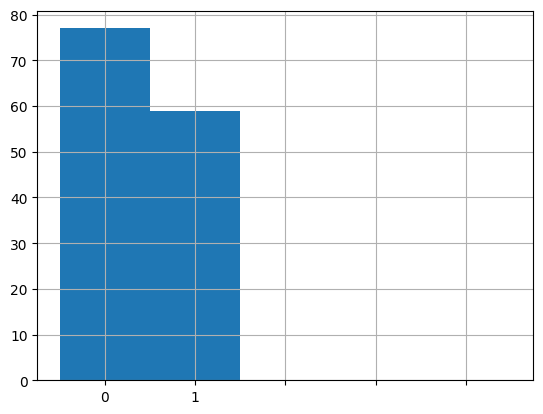

In [6]:
print(test_df['Outcome'].value_counts())

#GRAPH
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info


In [7]:
import joblib
rf_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_RF_morgan.pkl')  
rf_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_RF_maccskey.pkl')
rf_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_RF_modred.pkl')

svm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_SVM_morgan.pkl')  
svm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_SVM_maccskey.pkl')
svm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_SVM_modred.pkl')

xgb_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_XGB_morgan.pkl')  
xgb_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_XGB_maccskey.pkl')
xgb_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_XGB_modred.pkl')

gpc_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_GPC_morgan.pkl')  
gpc_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_GPC_maccskey.pkl')
gpc_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_GPC_modred.pkl')

nn_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_NN_morgan.pkl')  
nn_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_NN_maccskey.pkl')
nn_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_NN_modred.pkl')

lgbm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_LGBM_morgan.pkl')  
lgbm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_LGBM_maccskey.pkl')
lgbm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_LGBM_modred.pkl')

cbm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_CBM_morgan.pkl')  
cbm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_CBM_maccskey.pkl')
cbm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Inhalation toxicity/model - pribadi/fingerprint descriptor (model)/Model_inhalation_toxicity_CBM_modred.pkl')

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report


In [9]:
y_true = test_df['Outcome'].astype(int)  


In [10]:
# Consensus with probability average 

def predict_with_models_probabilities(moldf):
    # Assuming `predict_proba` method is available and returns probabilities for the positive class
    morgan_probs = rf_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = rf_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = rf_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs], axis=0)
   # mean_probs = np.mean([morgan_probs, maccs_probs], axis=0)
   # mean_probs = np.mean([maccs_probs, modred_probs], axis=0)
    # Convert mean probabilities to final class predictions (e.g., threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions

# Run prediction
final_predictions = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions

print(test_df[['SMILES', 'Predictions']])

                                                SMILES  Predictions
46                                CCCCCCCCCCCCCC(=O)OC            0
64                                CO[SiH](CC1CCCCC1)OC            0
63                                                NC=O            1
102         CCO[Si](CCCSSCCC[Si](OCC)(OCC)OCC)(OCC)OCC            0
61                           CCCCCCCCCCOC(=O)C(CC)CCCC            0
..                                                 ...          ...
45                                                O=CO            1
43                                        Nc1ccc(N)cc1            1
41                                       CC(C)(C)N=C=O            1
55   CCNc1cc2[o+]c3cc(NCC)c(C)cc3c(-c3ccccc3C(=O)OC...            0
135                                          NNC(=S)NN            1

[136 rows x 2 columns]


In [12]:
def predict_with_models_probabilities(test_df):
 
    morgan_probs = rf_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = rf_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = rf_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs], axis=0)
    
    # Convert mean probabilities to final class predictions (e.g., threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions, mean_probs

# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs



from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)


auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary') 
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp)
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn)
print("NPV (Negative Predictive Value):", npv)


Confusion Matrix:
[[55 22]
 [14 45]]
Accuracy: 0.7352941176470589
AUC Score: 0.8046445080343385
F1 Score: 0.7142857142857143
Sensitivity: 0.7627118644067796
Specificity: 0.7142857142857143
CCR (Correct Classification Rate): 0.7384987893462469
PPV (Positive Predictive Value): 0.6716417910447762
NPV (Negative Predictive Value): 0.7971014492753623


In [13]:
#RF
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = rf_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = rf_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[50 27]
 [21 38]]
Accuracy: 0.6470588235294118
AUC Score: 0.7169271406559542
F1 Score: 0.6129032258064516
Sensitivity: 0.6440677966101694
Specificity: 0.6493506493506493
CCR (Correct Classification Rate): 0.6467092229804094
PPV (Positive Predictive Value): 0.5846153846153846
NPV (Negative Predictive Value): 0.704225352112676

MACCS Performance:
Confusion Matrix: [[55 22]
 [12 47]]
Accuracy: 0.75
AUC Score: 0.7960598723310588
F1 Score: 0.734375
Sensitivity: 0.7966101694915254
Specificity: 0.7142857142857143
CCR (Correct Classification Rate): 0.7554479418886199
PPV (Positive Predictive Value): 0.6811594202898551
NPV (Negative Predictive Value): 0.8208955223880597

Modred Performance:
Confusion Matrix: [[60 17]
 [15 44]]
Accuracy: 0.7647058823529411
AUC Score: 0.7951793968743122
F1 Score: 0.7333333333333333
Sensitivity: 0.7457627118644068
Specificity: 0.7792207792207793
CCR (Correct Classification Rate): 0.762491745542593
PPV (Positive Predictive Val

In [14]:
#SVM
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = svm_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = svm_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = svm_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[52 25]
 [19 40]]
Accuracy: 0.6764705882352942
AUC Score: 0.7109839313229143
F1 Score: 0.6451612903225806
Sensitivity: 0.6779661016949152
Specificity: 0.6753246753246753
CCR (Correct Classification Rate): 0.6766453885097953
PPV (Positive Predictive Value): 0.6153846153846154
NPV (Negative Predictive Value): 0.7323943661971831

MACCS Performance:
Confusion Matrix: [[55 22]
 [11 48]]
Accuracy: 0.7573529411764706
AUC Score: 0.796830288355712
F1 Score: 0.7441860465116279
Sensitivity: 0.8135593220338984
Specificity: 0.7142857142857143
CCR (Correct Classification Rate): 0.7639225181598064
PPV (Positive Predictive Value): 0.6857142857142857
NPV (Negative Predictive Value): 0.8333333333333334

Modred Performance:
Confusion Matrix: [[51 26]
 [18 41]]
Accuracy: 0.6764705882352942
AUC Score: 0.7149460708782743
F1 Score: 0.6507936507936508
Sensitivity: 0.6949152542372882
Specificity: 0.6623376623376623
CCR (Correct Classification Rate): 0.6786264582874753
PPV

In [15]:
#XGB
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = xgb_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = xgb_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = xgb_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[49 28]
 [16 43]]
Accuracy: 0.6764705882352942
AUC Score: 0.7085626238168611
F1 Score: 0.6615384615384615
Sensitivity: 0.7288135593220338
Specificity: 0.6363636363636364
CCR (Correct Classification Rate): 0.6825885978428351
PPV (Positive Predictive Value): 0.6056338028169014
NPV (Negative Predictive Value): 0.7538461538461538

MACCS Performance:
Confusion Matrix: [[54 23]
 [13 46]]
Accuracy: 0.7352941176470589
AUC Score: 0.7922077922077922
F1 Score: 0.71875
Sensitivity: 0.7796610169491526
Specificity: 0.7012987012987013
CCR (Correct Classification Rate): 0.740479859123927
PPV (Positive Predictive Value): 0.6666666666666666
NPV (Negative Predictive Value): 0.8059701492537313

Modred Performance:
Confusion Matrix: [[63 14]
 [16 43]]
Accuracy: 0.7794117647058824
AUC Score: 0.7944089808496587
F1 Score: 0.7413793103448276
Sensitivity: 0.7288135593220338
Specificity: 0.8181818181818182
CCR (Correct Classification Rate): 0.773497688751926
PPV (Positive P

In [16]:
#NN
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = nn_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = nn_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = nn_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[47 30]
 [21 38]]
Accuracy: 0.625
AUC Score: 0.6955756108298481
F1 Score: 0.5984251968503937
Sensitivity: 0.6440677966101694
Specificity: 0.6103896103896104
CCR (Correct Classification Rate): 0.6272287034998899
PPV (Positive Predictive Value): 0.5588235294117647
NPV (Negative Predictive Value): 0.6911764705882353

MACCS Performance:
Confusion Matrix: [[55 22]
 [15 44]]
Accuracy: 0.7279411764705882
AUC Score: 0.8060752806515518
F1 Score: 0.704
Sensitivity: 0.7457627118644068
Specificity: 0.7142857142857143
CCR (Correct Classification Rate): 0.7300242130750605
PPV (Positive Predictive Value): 0.6666666666666666
NPV (Negative Predictive Value): 0.7857142857142857

Modred Performance:
Confusion Matrix: [[57 20]
 [15 44]]
Accuracy: 0.7426470588235294
AUC Score: 0.797490644948272
F1 Score: 0.7154471544715447
Sensitivity: 0.7457627118644068
Specificity: 0.7402597402597403
CCR (Correct Classification Rate): 0.7430112260620736
PPV (Positive Predictive Valu

In [17]:
#GPC
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = gpc_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = gpc_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = gpc_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[47 30]
 [18 41]]
Accuracy: 0.6470588235294118
AUC Score: 0.7074620294959278
F1 Score: 0.6307692307692307
Sensitivity: 0.6949152542372882
Specificity: 0.6103896103896104
CCR (Correct Classification Rate): 0.6526524323134493
PPV (Positive Predictive Value): 0.5774647887323944
NPV (Negative Predictive Value): 0.7230769230769231

MACCS Performance:
Confusion Matrix: [[52 25]
 [12 47]]
Accuracy: 0.7279411764705882
AUC Score: 0.8095971824785384
F1 Score: 0.7175572519083969
Sensitivity: 0.7966101694915254
Specificity: 0.6753246753246753
CCR (Correct Classification Rate): 0.7359674224081003
PPV (Positive Predictive Value): 0.6527777777777778
NPV (Negative Predictive Value): 0.8125

Modred Performance:
Confusion Matrix: [[59 18]
 [15 44]]
Accuracy: 0.7573529411764706
AUC Score: 0.789126128109179
F1 Score: 0.7272727272727273
Sensitivity: 0.7457627118644068
Specificity: 0.7662337662337663
CCR (Correct Classification Rate): 0.7559982390490865
PPV (Positive P

In [18]:
#LGBM
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = lgbm_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = lgbm_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = lgbm_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[50 27]
 [17 42]]
Accuracy: 0.6764705882352942
AUC Score: 0.7423508694695136
F1 Score: 0.65625
Sensitivity: 0.711864406779661
Specificity: 0.6493506493506493
CCR (Correct Classification Rate): 0.6806075280651551
PPV (Positive Predictive Value): 0.6086956521739131
NPV (Negative Predictive Value): 0.746268656716418

MACCS Performance:
Confusion Matrix: [[57 20]
 [13 46]]
Accuracy: 0.7573529411764706
AUC Score: 0.7919876733436056
F1 Score: 0.736
Sensitivity: 0.7796610169491526
Specificity: 0.7402597402597403
CCR (Correct Classification Rate): 0.7599603786044464
PPV (Positive Predictive Value): 0.696969696969697
NPV (Negative Predictive Value): 0.8142857142857143

Modred Performance:
Confusion Matrix: [[62 15]
 [14 45]]
Accuracy: 0.7867647058823529
AUC Score: 0.8038740920096853
F1 Score: 0.7563025210084033
Sensitivity: 0.7627118644067796
Specificity: 0.8051948051948052
CCR (Correct Classification Rate): 0.7839533348007924
PPV (Positive Predictive Valu

In [19]:
#CBM
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = cbm_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = cbm_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = cbm_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[47 30]
 [21 38]]
Accuracy: 0.625
AUC Score: 0.6671802773497689
F1 Score: 0.5984251968503937
Sensitivity: 0.6440677966101694
Specificity: 0.6103896103896104
CCR (Correct Classification Rate): 0.6272287034998899
PPV (Positive Predictive Value): 0.5588235294117647
NPV (Negative Predictive Value): 0.6911764705882353

MACCS Performance:
Confusion Matrix: [[53 24]
 [14 45]]
Accuracy: 0.7205882352941176
AUC Score: 0.8023332599603785
F1 Score: 0.703125
Sensitivity: 0.7627118644067796
Specificity: 0.6883116883116883
CCR (Correct Classification Rate): 0.725511776359234
PPV (Positive Predictive Value): 0.6521739130434783
NPV (Negative Predictive Value): 0.7910447761194029

Modred Performance:
Confusion Matrix: [[58 19]
 [16 43]]
Accuracy: 0.7426470588235294
AUC Score: 0.7985912392692054
F1 Score: 0.7107438016528925
Sensitivity: 0.7288135593220338
Specificity: 0.7532467532467533
CCR (Correct Classification Rate): 0.7410301562843935
PPV (Positive Predictive V

In [20]:
#Persiapan Consensus Deskriptor untuk masing-masing algoritma

import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix, accuracy_score, roc_auc_score, 
                             f1_score, precision_score)

X_morgan = np.vstack(test_df['Morgan_Descriptors'].values)
X_maccs  = np.vstack(test_df['MACCS_Descriptors'].values)
X_modred = np.vstack(test_df['Modred_Descriptor'].values)
y_true   = test_df['Outcome'].astype(int)

# Fungsi Evaluasi 
def print_consensus_result(algo_name, prob_morgan, prob_maccs, prob_modred, y_true):
    # Hitung Rata-rata Probabilitas (Consensus)
    mean_probs = np.mean([prob_morgan, prob_maccs, prob_modred], axis=0)
    # Threshold
    final_preds = (mean_probs > 0.5).astype(int)
    # Metrik
    cm = confusion_matrix(y_true, final_preds)
    tn, fp, fn, tp = cm.ravel()
    
    acc  = accuracy_score(y_true, final_preds)
    auc  = roc_auc_score(y_true, mean_probs)
    f1   = f1_score(y_true, final_preds)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv  = precision_score(y_true, final_preds, zero_division=0)
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0
    ccr  = (sens + spec) / 2
    
    print(f"Accuracy                         : {acc}")
    print(f"AUC Score                        : {auc}")
    print(f"F1 Score                         : {f1}")
    print(f"Sensitivity                      : {sens}")
    print(f"Specificity                      : {spec}")
    print(f"CCR (Correct Classification Rate): {ccr}")
    print(f"PPV (Positive Predictive Value)  : {ppv}")
    print(f"NPV (Negative Predictive Value)  : {npv}")

In [21]:
# Random Forest

#Load
prob_rf_morgan = rf_morgan.predict_proba(X_morgan)[:, 1]
prob_rf_maccs  = rf_maccs.predict_proba(X_maccs)[:, 1]
prob_rf_modred = rf_modred.predict_proba(X_modred)[:, 1]

#print
print_consensus_result("Random Forest", prob_rf_morgan, prob_rf_maccs, prob_rf_modred, y_true)

Accuracy                         : 0.7352941176470589
AUC Score                        : 0.8046445080343385
F1 Score                         : 0.7142857142857143
Sensitivity                      : 0.7627118644067796
Specificity                      : 0.7142857142857143
CCR (Correct Classification Rate): 0.7384987893462469
PPV (Positive Predictive Value)  : 0.6716417910447762
NPV (Negative Predictive Value)  : 0.7971014492753623


In [22]:
# SVM

# Helper function SVM - SVC
def get_svm_proba(model, X):
    try:
        return model.predict_proba(X)[:, 1]
    except AttributeError:
        # Jika probability=False , gunakan decision_function + sigmoid utk parameter
        d = model.decision_function(X)
        return 1 / (1 + np.exp(-d))

# load
prob_svm_morgan = get_svm_proba(svm_morgan, X_morgan)
prob_svm_maccs  = get_svm_proba(svm_maccs, X_maccs)
prob_svm_modred = get_svm_proba(svm_modred, X_modred)

# print
print_consensus_result("SVM", prob_svm_morgan, prob_svm_maccs, prob_svm_modred, y_true)

Accuracy                         : 0.6985294117647058
AUC Score                        : 0.7774598283072859
F1 Score                         : 0.672
Sensitivity                      : 0.711864406779661
Specificity                      : 0.6883116883116883
CCR (Correct Classification Rate): 0.7000880475456747
PPV (Positive Predictive Value)  : 0.6363636363636364
NPV (Negative Predictive Value)  : 0.7571428571428571


In [23]:
# XGBoosT

#load
prob_xgb_morgan = xgb_morgan.predict_proba(X_morgan)[:, 1]
prob_xgb_maccs  = xgb_maccs.predict_proba(X_maccs)[:, 1]
prob_xgb_modred = xgb_modred.predict_proba(X_modred)[:, 1]

#print
print_consensus_result("XGBoost", prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred, y_true)

Accuracy                         : 0.75
AUC Score                        : 0.8056350429231786
F1 Score                         : 0.7258064516129032
Sensitivity                      : 0.7627118644067796
Specificity                      : 0.7402597402597403
CCR (Correct Classification Rate): 0.75148580233326
PPV (Positive Predictive Value)  : 0.6923076923076923
NPV (Negative Predictive Value)  : 0.8028169014084507


In [24]:
# Neural Network

# load
prob_nn_morgan = nn_morgan.predict_proba(X_morgan)[:, 1]
prob_nn_maccs  = nn_maccs.predict_proba(X_maccs)[:, 1]
prob_nn_modred = nn_modred.predict_proba(X_modred)[:, 1]

# print
print_consensus_result("Neural Network", prob_nn_morgan, prob_nn_maccs, prob_nn_modred, y_true)

Accuracy                         : 0.7426470588235294
AUC Score                        : 0.8021131410961919
F1 Score                         : 0.72
Sensitivity                      : 0.7627118644067796
Specificity                      : 0.7272727272727273
CCR (Correct Classification Rate): 0.7449922958397535
PPV (Positive Predictive Value)  : 0.6818181818181818
NPV (Negative Predictive Value)  : 0.8


In [25]:
# GPC

# load
prob_gpc_morgan = gpc_morgan.predict_proba(X_morgan)[:, 1]
prob_gpc_maccs  = gpc_maccs.predict_proba(X_maccs)[:, 1]
prob_gpc_modred = gpc_modred.predict_proba(X_modred)[:, 1]

# print
print_consensus_result("GPC", prob_gpc_morgan, prob_gpc_maccs, prob_gpc_modred, y_true)

Accuracy                         : 0.7279411764705882
AUC Score                        : 0.8025533788245652
F1 Score                         : 0.7131782945736435
Sensitivity                      : 0.7796610169491526
Specificity                      : 0.6883116883116883
CCR (Correct Classification Rate): 0.7339863526304204
PPV (Positive Predictive Value)  : 0.6571428571428571
NPV (Negative Predictive Value)  : 0.803030303030303


In [30]:
# LGBM

#load
prob_lgbm_morgan = lgbm_morgan.predict_proba(X_morgan)[:, 1]
prob_lgbm_maccs  = lgbm_maccs.predict_proba(X_maccs)[:, 1]
prob_lgbm_modred = lgbm_modred.predict_proba(X_modred)[:, 1]

#print
print_consensus_result("LGBM", prob_lgbm_morgan, prob_lgbm_maccs, prob_lgbm_modred, y_true)

Accuracy                         : 0.7647058823529411
AUC Score                        : 0.8217037200088047
F1 Score                         : 0.7377049180327869
Sensitivity                      : 0.7627118644067796
Specificity                      : 0.7662337662337663
CCR (Correct Classification Rate): 0.7644728153202729
PPV (Positive Predictive Value)  : 0.7142857142857143
NPV (Negative Predictive Value)  : 0.8082191780821918


In [31]:
# CBM

#load
prob_cbm_morgan = cbm_morgan.predict_proba(X_morgan)[:, 1]
prob_cbm_maccs  = cbm_maccs.predict_proba(X_maccs)[:, 1]
prob_cbm_modred = cbm_modred.predict_proba(X_modred)[:, 1]

#print
print_consensus_result("CBM", prob_cbm_morgan, prob_cbm_maccs, prob_cbm_modred, y_true)

Accuracy                         : 0.6691176470588235
AUC Score                        : 0.7814219678626458
F1 Score                         : 0.6511627906976745
Sensitivity                      : 0.711864406779661
Specificity                      : 0.6363636363636364
CCR (Correct Classification Rate): 0.6741140215716487
PPV (Positive Predictive Value)  : 0.6
NPV (Negative Predictive Value)  : 0.7424242424242424


In [32]:
# Consensus SVM+RF+XGB+NN+GPC+LGBM+CBM

# hitung rata2 algoritma beserta descriptor
mean_prob_rf  = np.mean([prob_rf_morgan, prob_rf_maccs, prob_rf_modred], axis=0)
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_svm = np.mean([prob_svm_morgan, prob_svm_maccs, prob_svm_modred], axis=0)
mean_prob_nn  = np.mean([prob_nn_morgan, prob_nn_maccs, prob_nn_modred], axis=0)
mean_prob_gpc = np.mean([prob_gpc_morgan, prob_gpc_maccs, prob_gpc_modred], axis=0)
mean_prob_lgbm = np.mean([prob_lgbm_morgan, prob_lgbm_maccs, prob_lgbm_modred], axis=0)
mean_prob_cbm = np.mean([prob_cbm_morgan, prob_cbm_maccs, prob_cbm_modred], axis=0)



# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_rf, 
    mean_prob_xgb, 
    mean_prob_svm, 
    mean_prob_nn, 
    mean_prob_gpc,
    mean_prob_lgbm,
    mean_prob_cbm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.7205882352941176
AUC Score                        : 0.8166409861325116
F1 Score                         : 0.7076923076923077
Sensitivity                      : 0.7796610169491526
Specificity                      : 0.6753246753246753
CCR (Correct Classification Rate): 0.7274928461369139
PPV (Positive Predictive Value)  : 0.647887323943662
NPV (Negative Predictive Value)  : 0.8
[[52 25]
 [13 46]]


In [33]:
# Consensus SVM+RF+XGB

# hitung rata2 algoritma beserta descriptor
mean_prob_rf  = np.mean([prob_rf_morgan, prob_rf_maccs, prob_rf_modred], axis=0)
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_svm = np.mean([prob_svm_morgan, prob_svm_maccs, prob_svm_modred], axis=0)

# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_rf, 
    mean_prob_xgb, 
    mean_prob_svm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.7279411764705882
AUC Score                        : 0.8091569447501651
F1 Score                         : 0.7086614173228346
Sensitivity                      : 0.7627118644067796
Specificity                      : 0.7012987012987013
CCR (Correct Classification Rate): 0.7320052828527405
PPV (Positive Predictive Value)  : 0.6617647058823529
NPV (Negative Predictive Value)  : 0.7941176470588235
[[54 23]
 [14 45]]


In [34]:
# Consensus SVM+RF+XGB+LGBM+CBM

# hitung rata2 algoritma beserta descriptor
mean_prob_rf  = np.mean([prob_rf_morgan, prob_rf_maccs, prob_rf_modred], axis=0)
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_svm = np.mean([prob_svm_morgan, prob_svm_maccs, prob_svm_modred], axis=0)
mean_prob_lgbm = np.mean([prob_lgbm_morgan, prob_lgbm_maccs, prob_lgbm_modred], axis=0)
mean_prob_cbm = np.mean([prob_cbm_morgan, prob_cbm_maccs, prob_cbm_modred], axis=0)



# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_rf, 
    mean_prob_xgb, 
    mean_prob_svm, 
    mean_prob_lgbm,
    mean_prob_cbm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.7205882352941176
AUC Score                        : 0.8146599163548316
F1 Score                         : 0.7076923076923077
Sensitivity                      : 0.7796610169491526
Specificity                      : 0.6753246753246753
CCR (Correct Classification Rate): 0.7274928461369139
PPV (Positive Predictive Value)  : 0.647887323943662
NPV (Negative Predictive Value)  : 0.8
[[52 25]
 [13 46]]


In [35]:
# Consensus XGB+LGBM+CBM

# hitung rata2 algoritma beserta descriptor
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_lgbm = np.mean([prob_lgbm_morgan, prob_lgbm_maccs, prob_lgbm_modred], axis=0)
mean_prob_cbm = np.mean([prob_cbm_morgan, prob_cbm_maccs, prob_cbm_modred], axis=0)


# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_xgb, 
    mean_prob_lgbm,
    mean_prob_cbm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.75
AUC Score                        : 0.8093770636143518
F1 Score                         : 0.7301587301587301
Sensitivity                      : 0.7796610169491526
Specificity                      : 0.7272727272727273
CCR (Correct Classification Rate): 0.7534668721109399
PPV (Positive Predictive Value)  : 0.6865671641791045
NPV (Negative Predictive Value)  : 0.8115942028985508
[[56 21]
 [13 46]]


In [36]:
# Consensus SVM+RF+XGB+NN+CBM

# hitung rata2 algoritma beserta descriptor
mean_prob_rf  = np.mean([prob_rf_morgan, prob_rf_maccs, prob_rf_modred], axis=0)
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_svm = np.mean([prob_svm_morgan, prob_svm_maccs, prob_svm_modred], axis=0)
mean_prob_nn  = np.mean([prob_nn_morgan, prob_nn_maccs, prob_nn_modred], axis=0)
mean_prob_cbm = np.mean([prob_cbm_morgan, prob_cbm_maccs, prob_cbm_modred], axis=0)



# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_rf, 
    mean_prob_xgb, 
    mean_prob_svm, 
    mean_prob_nn, 
    mean_prob_cbm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.7205882352941176
AUC Score                        : 0.811798371120405
F1 Score                         : 0.7076923076923077
Sensitivity                      : 0.7796610169491526
Specificity                      : 0.6753246753246753
CCR (Correct Classification Rate): 0.7274928461369139
PPV (Positive Predictive Value)  : 0.647887323943662
NPV (Negative Predictive Value)  : 0.8
[[52 25]
 [13 46]]


In [37]:
# Consensus SVM+RF+XGB+NN+LGBM

# hitung rata2 algoritma beserta descriptor
mean_prob_rf  = np.mean([prob_rf_morgan, prob_rf_maccs, prob_rf_modred], axis=0)
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_svm = np.mean([prob_svm_morgan, prob_svm_maccs, prob_svm_modred], axis=0)
mean_prob_nn  = np.mean([prob_nn_morgan, prob_nn_maccs, prob_nn_modred], axis=0)
mean_prob_lgbm = np.mean([prob_lgbm_morgan, prob_lgbm_maccs, prob_lgbm_modred], axis=0)


# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_rf, 
    mean_prob_xgb, 
    mean_prob_svm, 
    mean_prob_nn, 
    mean_prob_lgbm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.7352941176470589
AUC Score                        : 0.8199427690953115
F1 Score                         : 0.71875
Sensitivity                      : 0.7796610169491526
Specificity                      : 0.7012987012987013
CCR (Correct Classification Rate): 0.740479859123927
PPV (Positive Predictive Value)  : 0.6666666666666666
NPV (Negative Predictive Value)  : 0.8059701492537313
[[54 23]
 [13 46]]


In [38]:
# Consensus SVM+RF+XGB+NN+LGBM+CBM

# hitung rata2 algoritma beserta descriptor
mean_prob_rf  = np.mean([prob_rf_morgan, prob_rf_maccs, prob_rf_modred], axis=0)
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_svm = np.mean([prob_svm_morgan, prob_svm_maccs, prob_svm_modred], axis=0)
mean_prob_nn  = np.mean([prob_nn_morgan, prob_nn_maccs, prob_nn_modred], axis=0)
mean_prob_lgbm = np.mean([prob_lgbm_morgan, prob_lgbm_maccs, prob_lgbm_modred], axis=0)
mean_prob_cbm = np.mean([prob_cbm_morgan, prob_cbm_maccs, prob_cbm_modred], axis=0)


# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_rf, 
    mean_prob_xgb, 
    mean_prob_svm, 
    mean_prob_nn, 
    mean_prob_lgbm,
    mean_prob_cbm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.7279411764705882
AUC Score                        : 0.8168611049966983
F1 Score                         : 0.7131782945736435
Sensitivity                      : 0.7796610169491526
Specificity                      : 0.6883116883116883
CCR (Correct Classification Rate): 0.7339863526304204
PPV (Positive Predictive Value)  : 0.6571428571428571
NPV (Negative Predictive Value)  : 0.803030303030303
[[53 24]
 [13 46]]
